# Eksploracyjna analiza danych

In [1]:
import pandas as pd
import seaborn as sns

## Część 1

Wykonaj wykresy pudełkowe (ang.box plot), które pozwolą na graficzną identyfikację wartości odstających poprzez przedstawienie kwartyli i wartości skrajnych w danych. Wykresy wykonaj dla danych pogrupowanych według miesięcy lub lat:

1. Średniej temperatury powietrza

In [2]:
daily_weather = pd.read_csv('data/daily_weather.csv')
daily_weather['date'] = pd.to_datetime(daily_weather['date'])

daily_weather['month'] = pd.to_datetime(daily_weather['date']).dt.month

extreme_weather = pd.read_csv('data/extreme_weather.csv')

extreme_weather['month'] = pd.to_datetime(extreme_weather['date']).dt.month

daily_weather

/tmp/ipykernel_246196/203075811.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_weather = pd.read_csv('data/daily_weather.csv')
/tmp/ipykernel_246196/203075811.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  extreme_weather = pd.read_csv('data/extreme_weather.csv')


,stn,wban,temp,dewp,slp,stp,visib,wdsp,prcp,sndp,date,name,country,lat,lon,elev,month
0,010580,NaN,22.2,20.3,1009.7,962.2,NaN,9.9,0.0,NaN,2020-11-30,SUOLOVUOPMI LULIT,NO,69.567,23.533,381.0,11
1,011330,NaN,28.8,24.7,NaN,999.9,NaN,4.7,0.0,NaN,2020-12-22,LAKSFORS,NO,65.617,13.283,50.0,12
2,011980,NaN,54.4,43.2,1018.5,994.0,NaN,NaN,0.0,NaN,2020-09-02,DIVIDALEN II,NO,68.783,19.700,204.0,9
3,012120,NaN,57.7,50.8,1002.7,1.0,NaN,39.4,0.0,NaN,2020-09-21,ONA II,NO,62.867,6.533,15.0,9
4,012900,NaN,39.6,39.2,NaN,999.9,6.2,4.5,0.0,NaN,2020-10-31,NAMSOS AIRPORT,NO,64.467,11.583,2.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4105715,A51256,451.0,47.3,43.7,NaN,974.2,8.6,5.6,0.0,NaN,2020-03-10,BRANSON WEST MUNICIPAL EMERSO,US,36.699,-93.402,411.2,3
4105716,A51256,451.0,24.2,17.6,NaN,984.7,10.0,7.2,0.0,NaN,2020-01-21,BRANSON WEST MUNICIPAL EMERSO,US,36.699,-93.402,411.2,1
4105717,A51256,451.0,76.8,73.0,NaN,953.9,7.0,9.8,NaN,NaN,2020-06-09,BRANSON WEST MUNICIPAL EMERSO,US,36.699,-93.402,411.2,6
4105718,A51256,451.0,39.5,33.5,NaN,968.0,6.3,3.7,0.0,NaN,2020-12-20,BRANSON WEST MUNICIPAL EMERSO,US,36.699,-93.402,411.2,12


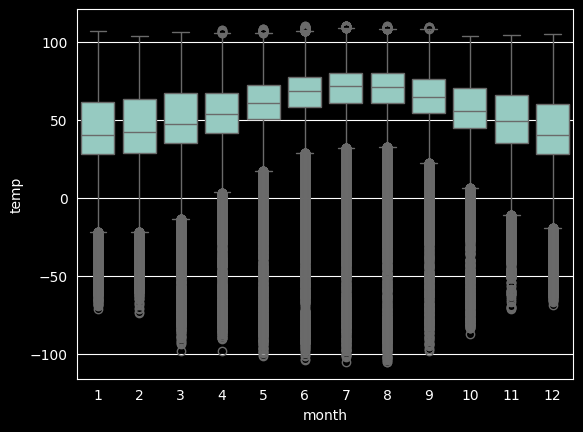

In [3]:
sns.boxplot(daily_weather, x='month', y='temp');

2. Maksymalnej temperatury

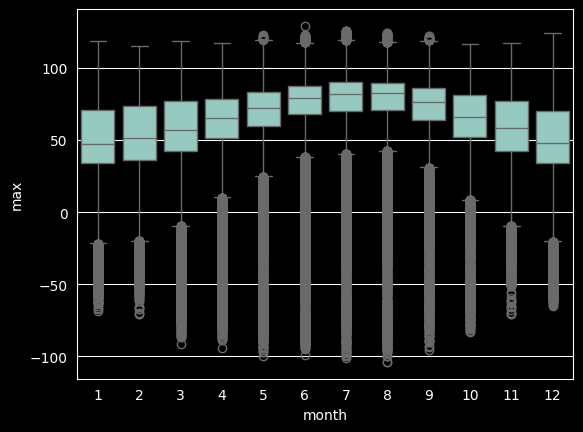

In [4]:
sns.boxplot(extreme_weather, x='month', y='max');

3. Minimalnej temperatury

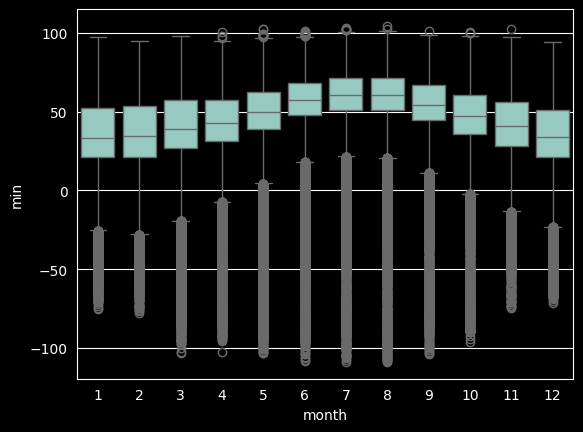

In [5]:
sns.boxplot(extreme_weather, x='month', y='min');

4. Opadów atmosferycznych

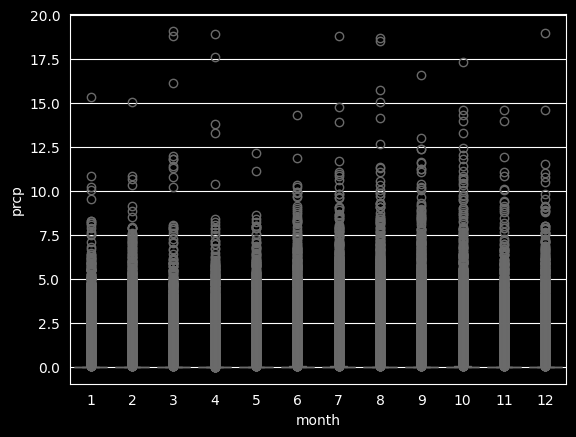

In [6]:
sns.boxplot(daily_weather, x='month', y='prcp');

5. Prędkości wiatru

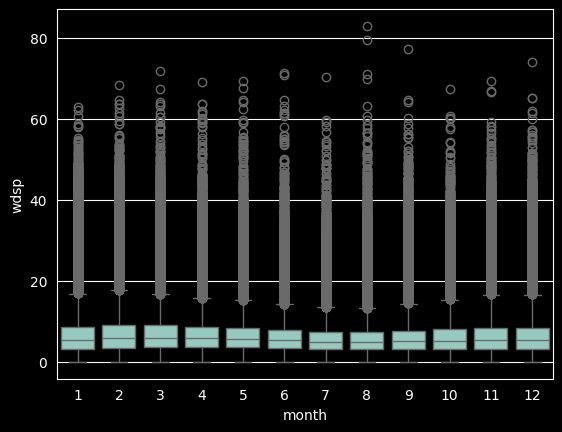

In [7]:
sns.boxplot(daily_weather, x='month', y='wdsp');

6. Widzialności

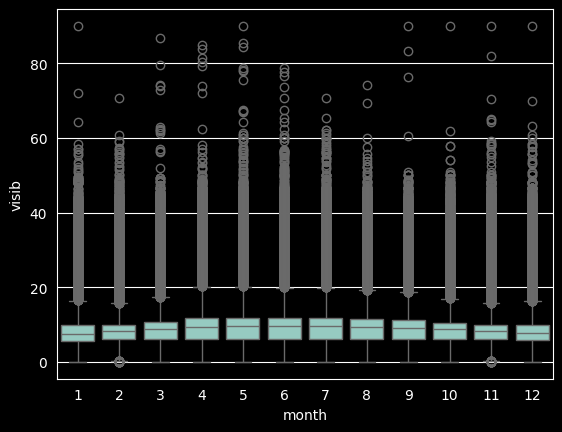

In [8]:
sns.boxplot(daily_weather, x='month', y='visib');

7. co najmniej 4 innych informacji ze zbioru danych, które uznasz za istotne

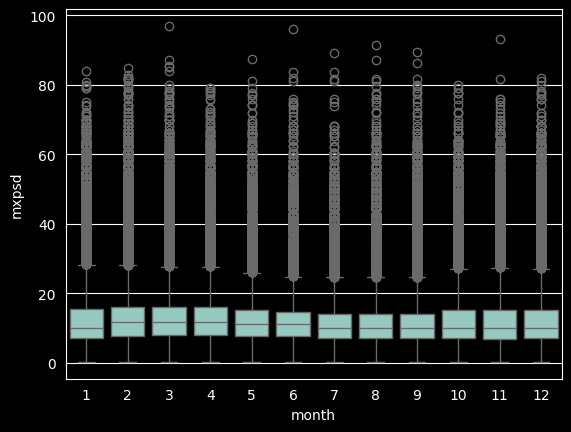

In [9]:
sns.boxplot(extreme_weather, x='month', y='mxpsd');

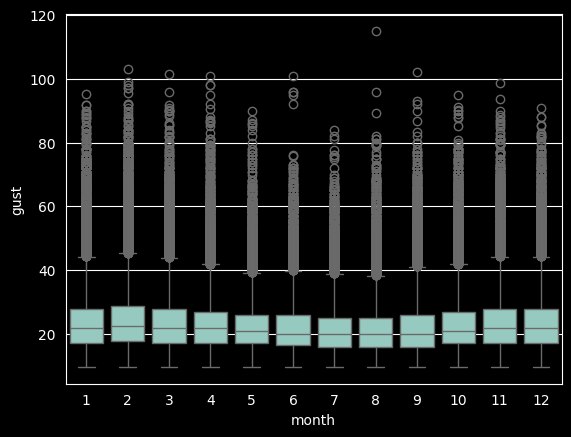

In [10]:
sns.boxplot(extreme_weather, x='month', y='gust');

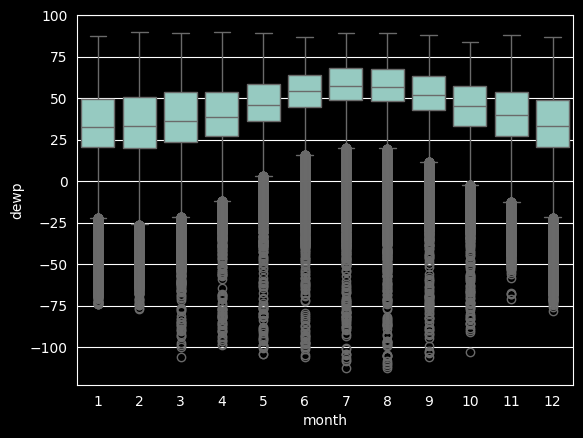

In [11]:
sns.boxplot(daily_weather, x='month', y='dewp');

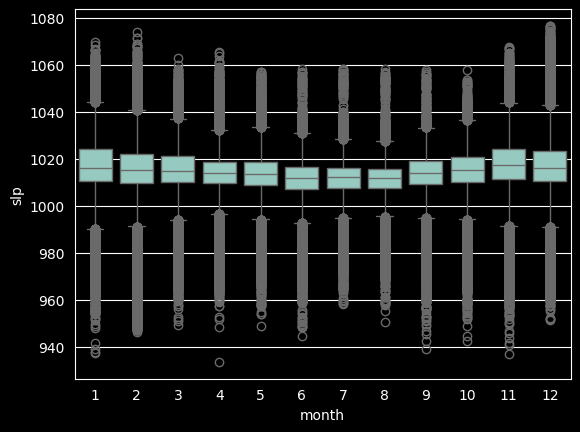

In [12]:
sns.boxplot(daily_weather, x='month', y='slp');

## Część 2 - misja dodatkowa

Zostawiamy

In [13]:
q1 = daily_weather.groupby('country')['temp'].transform(lambda x: x.quantile(0.25))
q3 = daily_weather.groupby('country')['temp'].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily_weather[(daily_weather['temp'] < lower_bound) | (daily_weather['temp'] > upper_bound)]

outliers

,stn,wban,temp,dewp,slp,stp,visib,wdsp,prcp,sndp,date,name,country,lat,lon,elev,month
58,246910,NaN,-35.2,-41.7,1028.9,917.3,21.7,NaN,0.00,7.5,2020-11-30,DELYANKIR,RS,63.833,145.600,800.9,11
59,250440,NaN,-32.5,-35.5,1022.4,21.7,12.4,4.4,0.00,14.2,2020-01-23,RAUCHUA,RS,69.500,166.583,4.6,1
161,420810,NaN,51.1,32.1,NaN,893.7,2.5,0.0,0.00,NaN,2020-12-22,BHUNTAR,IN,31.833,77.167,1084.0,12
178,422950,NaN,56.5,44.5,NaN,804.4,2.6,0.0,0.00,NaN,2020-02-29,DARJEELING,IN,27.050,88.267,2128.0,2
276,480010,NaN,59.5,49.2,1013.8,64.6,2.4,0.7,0.00,NaN,2020-01-12,PUTAO,BM,27.333,97.417,409.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4105430,999999,96409.0,-9.0,NaN,NaN,999.9,NaN,NaN,0.00,NaN,2020-02-29,TOOLIK LAKE 5 ENE,US,68.648,-149.399,750.1,2
4105482,999999,23583.0,-11.1,NaN,NaN,999.9,NaN,NaN,0.00,NaN,2020-01-31,ALEKNAGIK 1 NNE,US,59.284,-158.615,24.4,1
4105496,999999,96407.0,-29.4,NaN,NaN,999.9,NaN,NaN,0.00,NaN,2020-01-28,SELAWIK 28 E,US,66.562,-159.004,6.7,1
4105500,999999,96404.0,-3.8,NaN,NaN,999.9,NaN,NaN,0.02,NaN,2020-01-24,TOK 70 SE,US,62.737,-141.208,609.6,1


In [14]:
q1 = daily_weather.groupby('country')['prcp'].transform(lambda x: x.quantile(0.25))
q3 = daily_weather.groupby('country')['prcp'].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily_weather[(daily_weather['prcp'] < lower_bound) | (daily_weather['prcp'] > upper_bound)]
outliers

,stn,wban,temp,dewp,slp,stp,visib,wdsp,prcp,sndp,date,name,country,lat,lon,elev,month
15,085890,NaN,79.0,73.4,1013.4,999.9,4.7,7.2,0.67,NaN,2020-07-13,PRAIA,CV,14.933,-23.483,95.0,7
16,135760,NaN,46.6,36.2,NaN,867.2,10.9,14.1,0.14,3.9,2020-03-02,MAVROVO,MK,41.700,20.750,1240.0,3
24,167131,NaN,49.1,NaN,1009.4,7.1,NaN,2.7,0.31,NaN,2020-12-10,NAFPLION,GR,37.583,22.767,2.0,12
25,167380,NaN,54.6,49.6,1009.5,989.7,NaN,8.7,0.35,NaN,2020-12-10,MILOS,GR,36.733,24.433,168.4,12
27,170700,NaN,48.5,30.1,1021.0,933.5,9.3,0.0,0.31,NaN,2020-04-16,BOLU,TU,40.733,31.600,743.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4105632,999999,53878.0,62.4,NaN,NaN,999.9,NaN,NaN,0.48,NaN,2020-10-25,ASHEVILLE 13 S,US,35.419,-82.557,641.0,10
4105642,999999,63838.0,40.1,NaN,NaN,999.9,NaN,NaN,0.04,NaN,2020-12-24,VERSAILLES 3 NNW,US,38.095,-84.747,271.6,12
4105643,999999,63899.0,57.5,NaN,NaN,999.9,NaN,3.6,0.01,NaN,2020-02-20,BREWTON 3 NNE,US,31.145,-87.052,51.8,2
4105677,A00024,53848.0,77.3,67.7,1009.8,4.5,9.4,16.9,0.07,NaN,2020-10-29,CHOCTAW NAVAL OUTLYING FIELD,US,30.507,-86.960,31.1,10


## Część 3

1. Zidentyfikuj brakujące wartości w zbiorze, sprawdź liczbę braków w poszczególnych kolumnach oraz określ ich udział procentowy.

In [15]:
pd.DataFrame({'Liczba braków': daily_weather.isnull().sum(), 'Procent (%)': daily_weather.isnull().mean() * 100})

,Liczba braków,Procent (%)
stn,0,0.000000
wban,3274875,79.763720
temp,0,0.000000
dewp,201956,4.918894
slp,1400365,34.107660
stp,0,0.000000
visib,1108138,26.990102
wdsp,162897,3.967562
prcp,303060,7.381409
sndp,3833288,93.364574


2. Sprawdź, czy w zbiorze występują wartości liczbowe oznaczające brak danych i w razie potrzeby zamień je na wartości brakujące.

Nie występują takie wartości, zostały zamienione na null w poprzednim zadaniu.

3. Wybierz co najmniej dwie zmienne pogodowe i uzupełnij brakujące wartości stosując różne metody imputacji: średnia, mediana, interpolacja w czasie.

In [16]:
imputated = daily_weather[['stn', 'wban', 'dewp', 'prcp', 'date', 'name', 'country', 'month']].copy()
imputated['mean_prcp'] = imputated.groupby(['name', 'month'])['prcp'].transform(lambda g: g.fillna(g.mean()))
imputated['median_prcp'] = imputated.groupby(['name', 'month'])['prcp'].transform(lambda g: g.fillna(g.median()))
imputated['interpolate_prcp'] = imputated.groupby(['name', 'month'])['prcp'].transform(lambda g: g.interpolate(method='linear'))

imputated['mean_dewp'] = imputated.groupby(['name', 'month'])['dewp'].transform(lambda g: g.fillna(g.mean()))
imputated['median_dewp'] = imputated.groupby(['name', 'month'])['dewp'].transform(lambda g: g.fillna(g.median()))
imputated['interpolate_dewp'] = imputated.groupby(['name', 'month'])['dewp'].transform(lambda g: g.interpolate(method='linear'))

# step 2
imputated['mean_prcp'] = imputated['mean_prcp'].fillna(daily_weather.groupby('name')['prcp'].transform('mean'))
imputated['median_prcp'] = imputated['median_prcp'].fillna(daily_weather.groupby('name')['prcp'].transform('median'))
imputated['interpolate_prcp'] = imputated['interpolate_prcp'].fillna(daily_weather.groupby('name')['prcp'].transform(lambda g: g.interpolate(method='linear', limit_direction='both')))

imputated['mean_dewp'] = imputated['mean_dewp'].fillna(daily_weather.groupby('name')['dewp'].transform('mean'))
imputated['median_dewp'] = imputated['median_dewp'].fillna(daily_weather.groupby('name')['dewp'].transform('median'))
imputated['interpolate_dewp'] = imputated['interpolate_dewp'].fillna(daily_weather.groupby('name')['dewp'].transform(lambda g: g.interpolate(method='linear', limit_direction='both')))

# step 3
imputated['mean_prcp'] = imputated['mean_prcp'].fillna(daily_weather['prcp'].mean())
imputated['median_prcp'] = imputated['median_prcp'].fillna(daily_weather['prcp'].median())
imputated['interpolate_prcp'] = imputated['interpolate_prcp'].fillna(daily_weather['prcp'].interpolate(method='linear'))

imputated['mean_dewp'] = imputated['mean_dewp'].fillna(daily_weather['dewp'].mean())
imputated['median_dewp'] = imputated['median_dewp'].fillna(daily_weather['dewp'].median())
imputated['interpolate_dewp'] = imputated['interpolate_dewp'].fillna(daily_weather['dewp'].interpolate(method='linear'))
imputated

/mnt/disk/JetBrainsProjects/PycharmProjects/PodstawyPrzetwarzaniaDuzychZbiorowDanych/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/mnt/disk/JetBrainsProjects/PycharmProjects/PodstawyPrzetwarzaniaDuzychZbiorowDanych/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/mnt/disk/JetBrainsProjects/PycharmProjects/PodstawyPrzetwarzaniaDuzychZbiorowDanych/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/mnt/disk/JetBrainsProjects/PycharmProjects/PodstawyPrzetwarzaniaDuzychZbiorowDanych/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdi

,stn,wban,dewp,prcp,date,name,country,month,mean_prcp,median_prcp,interpolate_prcp,mean_dewp,median_dewp,interpolate_dewp
0,010580,NaN,20.3,0.0,2020-11-30,SUOLOVUOPMI LULIT,NO,11,0.0,0.0,0.0,20.3,20.3,20.3
1,011330,NaN,24.7,0.0,2020-12-22,LAKSFORS,NO,12,0.0,0.0,0.0,24.7,24.7,24.7
2,011980,NaN,43.2,0.0,2020-09-02,DIVIDALEN II,NO,9,0.0,0.0,0.0,43.2,43.2,43.2
3,012120,NaN,50.8,0.0,2020-09-21,ONA II,NO,9,0.0,0.0,0.0,50.8,50.8,50.8
4,012900,NaN,39.2,0.0,2020-10-31,NAMSOS AIRPORT,NO,10,0.0,0.0,0.0,39.2,39.2,39.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4105715,A51256,451.0,43.7,0.0,2020-03-10,BRANSON WEST MUNICIPAL EMERSO,US,3,0.0,0.0,0.0,43.7,43.7,43.7
4105716,A51256,451.0,17.6,0.0,2020-01-21,BRANSON WEST MUNICIPAL EMERSO,US,1,0.0,0.0,0.0,17.6,17.6,17.6
4105717,A51256,451.0,73.0,NaN,2020-06-09,BRANSON WEST MUNICIPAL EMERSO,US,6,0.0,0.0,0.0,73.0,73.0,73.0
4105718,A51256,451.0,33.5,0.0,2020-12-20,BRANSON WEST MUNICIPAL EMERSO,US,12,0.0,0.0,0.0,33.5,33.5,33.5


4. Porównaj otrzymane wyniki dla różnych metod imputacji i uzasadnij wybór metody, którą uznasz za najbardziej odpowiednią.

In [17]:
pd.DataFrame({'Liczba braków': imputated.isnull().sum(), 'Procent (%)': imputated.isnull().mean() * 100}).loc[['prcp', 'mean_prcp', 'median_prcp', 'interpolate_prcp', 'dewp', 'mean_dewp', 'median_dewp', 'interpolate_dewp']]

,Liczba braków,Procent (%)
prcp,303060,7.381409
mean_prcp,0,0.000000
median_prcp,0,0.000000
interpolate_prcp,0,0.000000
dewp,201956,4.918894
mean_dewp,0,0.000000
median_dewp,0,0.000000
interpolate_dewp,0,0.000000


In [18]:
imputated.describe()[['prcp', 'mean_prcp', 'median_prcp', 'interpolate_prcp', 'dewp', 'mean_dewp', 'median_dewp', 'interpolate_dewp']].T

,count,mean,min,25%,50%,75%,max,std
prcp,3802660.0,0.075445,0.0,0.0,0.0,0.01,19.09,0.302722
mean_prcp,4105720.0,0.071769,0.0,0.0,0.0,0.01,19.09,0.292516
median_prcp,4105720.0,0.070092,0.0,0.0,0.0,0.01,19.09,0.292041
interpolate_prcp,4105720.0,0.071774,0.0,0.0,0.0,0.01,19.09,0.294547
dewp,3903764.0,44.314778,-112.6,31.3,45.7,59.70,89.90,21.174088
mean_dewp,4105720.0,44.301585,-112.6,32.0,44.5,59.00,89.90,20.716426
median_dewp,4105720.0,44.363323,-112.6,32.0,45.7,59.00,89.90,20.719509
interpolate_dewp,4105720.0,44.414128,-112.6,31.5,45.8,59.80,89.90,21.050624


Wybraliśmy imputacje średnią dla prcp i medianą dla dewp

In [19]:
daily_weather['prcp'] = imputated['mean_prcp']
daily_weather['dewp'] = imputated['median_dewp']

In [20]:
daily_weather.to_csv('data/daily_weather_imputed.csv', index=False)

## Część 4 tylko na pogodowych

1. Średnia temperatura, opady i prędkość wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu.

In [21]:
daily_weather[daily_weather['date'].dt.month == 4].groupby('country')[['temp', 'prcp', 'wdsp']].mean()

,temp,prcp,wdsp
country,,,
AA,83.080000,0.000000,17.566667
AC,79.391667,0.010833,3.753333
AE,84.227074,0.004606,6.750218
AF,62.153631,0.162700,4.215084
AG,70.058464,0.043386,7.189371
...,...,...,...
WQ,79.250000,0.000000,11.093333
WS,82.003571,0.249643,5.260714
WZ,68.254839,0.046065,3.223077


2. Średnia zmiana temperatury i opadów dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu.


In [22]:
df_sorted = daily_weather.sort_values(by=['country', 'date'])
df_sorted['mean_temp_change'] = df_sorted.groupby('country')['temp'].diff()
df_sorted['mean_prcp_change'] = df_sorted.groupby('country')['prcp'].diff()

df_sorted.groupby('country')[['mean_temp_change', 'mean_prcp_change']].mean()

,mean_temp_change,mean_prcp_change
country,,
AA,-0.012877,5.260274e-03
AC,-0.000825,0.000000e+00
AE,-0.000514,7.609479e-20
AF,0.001169,1.948368e-05
AG,0.000602,3.797712e-21
...,...,...
WQ,0.011776,0.000000e+00
WS,0.000581,-1.598837e-04
WZ,-0.002510,-1.004016e-05


3. Mediana temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu.

In [23]:
daily_weather[daily_weather['date'].dt.month == 4].groupby('country')[['temp', 'prcp', 'wdsp']].median()

,temp,prcp,wdsp
country,,,
AA,83.15,0.00,17.70
AC,79.35,0.00,1.60
AE,84.50,0.00,6.40
AF,63.80,0.00,4.10
AG,66.80,0.00,6.60
...,...,...,...
WQ,79.45,0.00,11.30
WS,82.10,0.02,5.30
WZ,67.80,0.00,2.75


4. Odchylenie standardowe temperatury, opadów i prędkości wiatru.

In [24]:
daily_weather[daily_weather['date'].dt.month == 4].groupby('country')[['temp', 'prcp', 'wdsp']].std()

,temp,prcp,wdsp
country,,,
AA,0.435019,0.000000,1.894153
AC,1.167540,0.025331,4.148901
AE,5.489788,0.023142,2.114499
AF,10.931545,0.502864,2.593086
AG,11.192297,0.162332,4.126746
...,...,...,...
WQ,1.073170,0.000000,3.530586
WS,1.473396,0.573059,1.901739
WZ,5.723887,0.290616,2.101625


5. Minimalna, średnia i maksymalna temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów.

In [25]:
daily_weather[daily_weather['date'].dt.month == 4].groupby('country')[['temp', 'prcp', 'wdsp']].agg(['min', 'mean', 'max']).T

country           AA         AC         AE         AF          AG         AJ  \
temp min   81.900000  75.100000  73.600000  37.400000   42.300000  32.500000   
     mean  83.080000  79.391667  84.227074  62.153631   70.058464  52.187879   
     max   83.700000  81.200000  94.500000  83.000000  102.700000  70.900000   
prcp min    0.000000   0.000000   0.000000   0.000000    0.000000   0.000000   
     mean   0.000000   0.010833   0.004606   0.162700    0.043386   0.353091   
     max    0.000000   0.110000   0.270000   3.860000    2.050000   3.920000   
wdsp min   12.900000   0.000000   3.400000   0.000000    0.000000   1.900000   
     mean  17.566667   3.753333   6.750218   4.215084    7.189371   5.749231   
     max   21.500000  11.000000  13.500000  17.300000   26.500000  22.500000   

country           AL         AM         AO         AQ  ...         VM  \
temp min   31.100000  24.000000  64.300000  78.700000  ...  45.700000   
     mean  56.713030  43.960938  77.776066  83.046667  ...  77.172000   
     max   69.200000  62.300000  89.600000  85.600000  ...  91.900000   
prcp min    0.000000   0.000000   0.000000   0.000000  ...   0.000000   
     mean   0.067970   0.158192   0.078892   0.532667  ...   0.113587   
     max    1.570000   3.930000   4.690000   2.670000  ...   5.440000   
wdsp min    0.000000   1.500000   0.700000   2.700000  ...   0.000000   
     mean   3.812121   4.021860   5.894098   6.690000  ...   5.003287   
     max   22.300000  14.400000  13.600000  14.100000  ...  21.900000   

country           VQ         WA         WF         WI         WQ         WS  \
temp min   76.500000  57.200000  79.500000  63.500000  76.600000  77.900000   
     mean  80.715833  70.273623  82.643243  68.177778  79.250000  82.003571   
     max   82.900000  85.000000  84.700000  72.400000  81.200000  85.900000   
prcp min    0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
     mean   0.000000   0.025449   0.362162   0.000222   0.000000   0.249643   
     max    0.000000   3.900000   7.850000   0.020000   0.000000   2.890000   
wdsp min    0.000000   0.000000   1.600000   2.900000   3.200000   1.000000   
     mean   2.565000   5.164058   4.416216  11.026667  11.093333   5.260714   
     max    8.600000  25.600000  10.400000  25.400000  18.400000  10.800000   

country           WZ         ZA         ZI  
temp min   51.600000  65.600000  59.600000  
     mean  68.254839  71.086667  70.316667  
     max   81.100000  81.900000  84.300000  
prcp min    0.000000   0.000000   0.000000  
     mean   0.046065   0.009667   0.000556  
     max    3.270000   0.200000   0.020000  
wdsp min    0.000000   1.700000   2.600000  
     mean   3.223077   5.343333   6.819444  
     max   11.200000   9.800000  15.000000  

[9 rows x 235 columns]

## Część 5

Wykonaj normalizację wybranych zmiennych przy użyciu tej samej metody skalowania (np. normalizacji min-max z zakresu [0,1]):
1. Temperatura
2. Opady
3. Prędkość wiatru
4. Wybrana zmienna rolnicza
5. Co najmniej 3 dodatkowe zmienne, które uznasz za istotne

In [26]:
from sklearn.preprocessing import  MinMaxScaler

faostat = pd.read_csv('data/weather_faostat_annual.csv')
to_norm = ['yearly_mean_temp', 'yearly_sum_prcp', 'yearly_mean_wdsp', 'value', 'yearly_mean_dewp', 'yearly_mean_stp', 'yearly_sum_sndp']

scaler = MinMaxScaler()

df_normalized = pd.DataFrame(
    scaler.fit_transform(faostat[to_norm]),
    columns=to_norm
)

faostat_joined = faostat.join(df_normalized, rsuffix='_norm')
faostat_joined

,country,station,yearly_mean_temp,yearly_mean_dewp,yearly_mean_slp,yearly_mean_stp,yearly_mean_visib,yearly_mean_wdsp,yearly_sum_prcp,yearly_sum_sndp,...,unit,value,flag_description,yearly_mean_temp_norm,yearly_sum_prcp_norm,yearly_mean_wdsp_norm,value_norm,yearly_mean_dewp_norm,yearly_mean_stp_norm,yearly_sum_sndp_norm
0,AE,ABU DHABI INTL,84.090909,63.458678,1008.4825,270.069146,5.825344,7.530028,3.14,0.0,...,ha,56.00,Official figure,0.844309,0.012260,0.229281,7.406716e-08,0.826695,0.267471,0.0
1,AE,ABU DHABI INTL,84.090909,63.458678,1008.4825,270.069146,5.825344,7.530028,3.14,0.0,...,kg/ha,7857.10,Official figure,0.844309,0.012260,0.229281,1.039202e-05,0.826695,0.267471,0.0
2,AE,ABU DHABI INTL,84.090909,63.458678,1008.4825,270.069146,5.825344,7.530028,3.14,0.0,...,t,440.00,Official figure,0.844309,0.012260,0.229281,5.819563e-07,0.826695,0.267471,0.0
3,AE,ABU DHABI INTL,84.090909,63.458678,1008.4825,270.069146,5.825344,7.530028,3.14,0.0,...,ha,14.00,Official figure,0.844309,0.012260,0.229281,1.851679e-08,0.826695,0.267471,0.0
4,AE,ABU DHABI INTL,84.090909,63.458678,1008.4825,270.069146,5.825344,7.530028,3.14,0.0,...,kg/ha,50000.00,Official figure,0.844309,0.012260,0.229281,6.613139e-05,0.826695,0.267471,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2882452,ZA,LUSAKA INTL,70.623851,53.676437,NaN,999.900000,8.132471,5.955747,22.68,0.0,...,t,2956.53,Value imputed by a receiving agency,0.733843,0.088552,0.181346,3.910389e-06,0.736512,1.000000,0.0
2882453,ZA,LUSAKA INTL,70.623851,53.676437,NaN,999.900000,8.132471,5.955747,22.68,0.0,...,t,6776.72,Value imputed by a receiving agency,0.733843,0.088552,0.181346,8.963079e-06,0.736512,1.000000,0.0
2882454,ZA,LUSAKA INTL,70.623851,53.676437,NaN,999.900000,8.132471,5.955747,22.68,0.0,...,t,7495.78,Value imputed by a receiving agency,0.733843,0.088552,0.181346,9.914127e-06,0.736512,1.000000,0.0
2882455,ZA,LUSAKA INTL,70.623851,53.676437,NaN,999.900000,8.132471,5.955747,22.68,0.0,...,t,43687.94,Value imputed by a receiving agency,0.733843,0.088552,0.181346,5.778289e-05,0.736512,1.000000,0.0


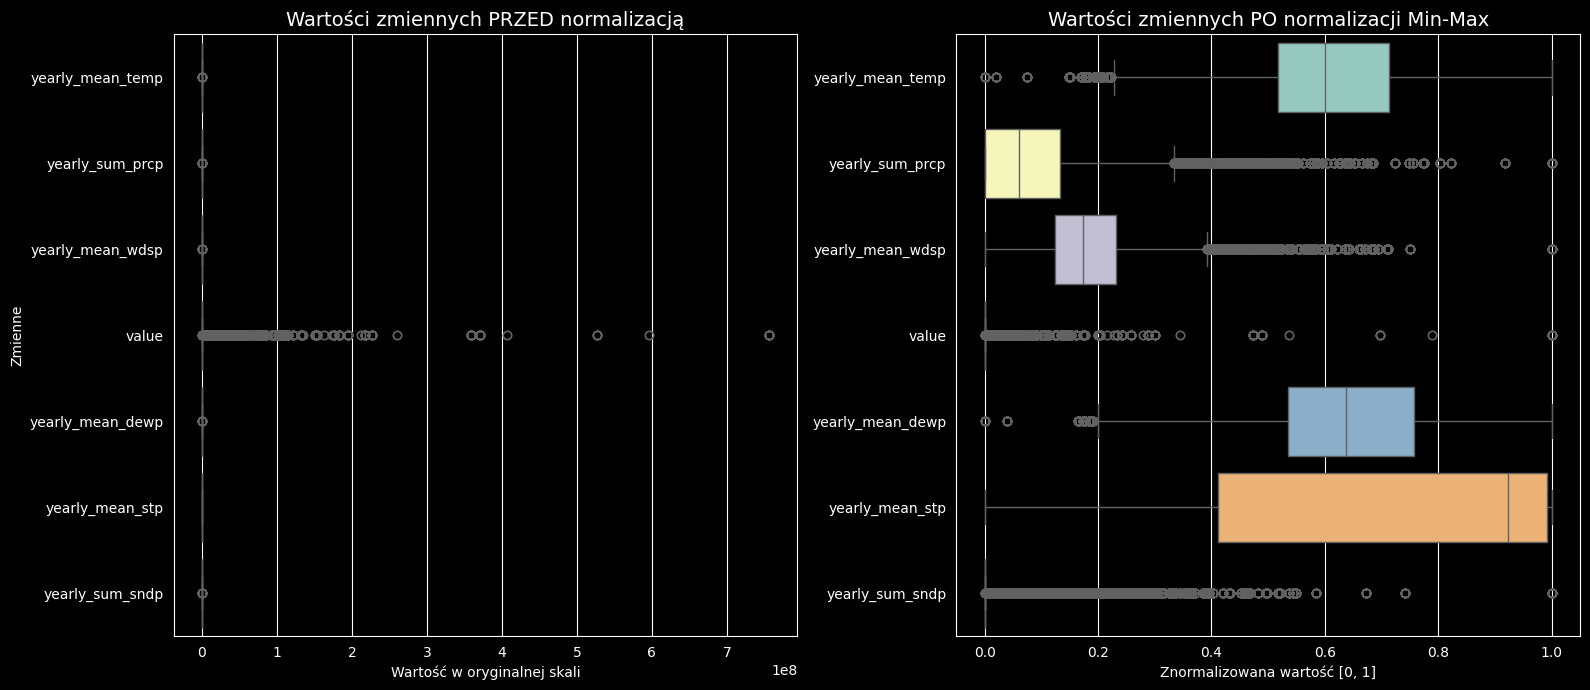

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# Wykres przed normalizacją
sns.boxplot(data=faostat[to_norm], ax=axes[0], orient='h')
axes[0].set_title('Wartości zmiennych PRZED normalizacją', fontsize=14)
axes[0].set_xlabel('Wartość w oryginalnej skali')
axes[0].set_ylabel('Zmienne')

# Wykres po normalizacji
sns.boxplot(data=df_normalized, ax=axes[1], orient='h')
axes[1].set_title('Wartości zmiennych PO normalizacji Min-Max', fontsize=14)
axes[1].set_xlabel('Znormalizowana wartość [0, 1]')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Część 6

In [28]:
daily_weather = None
extreme_weather = None
imputated = None
faostat_extreme = pd.read_csv('data/extreme_faostat_annual.csv')

faostat_merged = faostat.merge(faostat_extreme[faostat_extreme.columns.difference(faostat.columns).to_list() + ['country', 'element', 'item']], left_on=['country', 'station', 'element', 'item'], right_on=['country', 'station_name', 'element', 'item'])

corr = faostat_merged.corr(numeric_only=True)

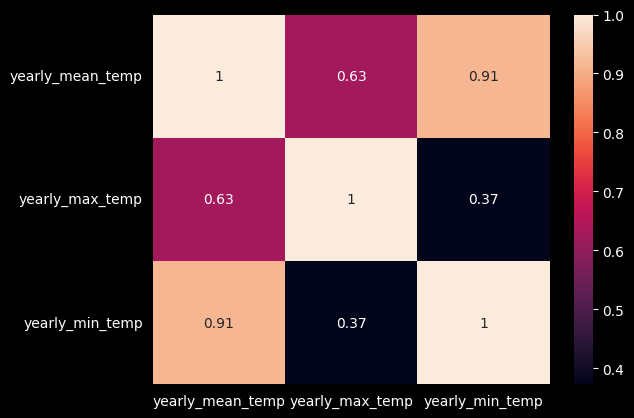

In [29]:
sns.heatmap(corr[['yearly_mean_temp', 'yearly_max_temp', 'yearly_min_temp']].loc[['yearly_mean_temp', 'yearly_max_temp', 'yearly_min_temp']], annot=True);

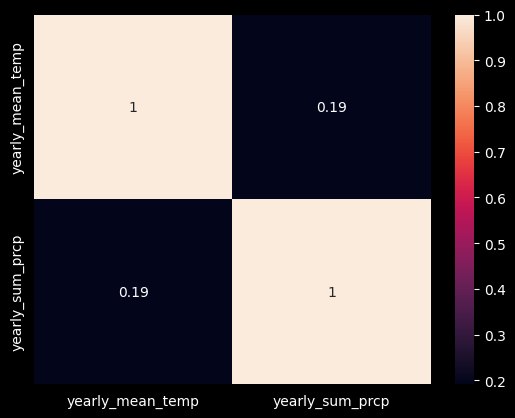

In [30]:
sns.heatmap(corr[['yearly_mean_temp', 'yearly_sum_prcp']].loc[['yearly_mean_temp', 'yearly_sum_prcp']], annot=True);

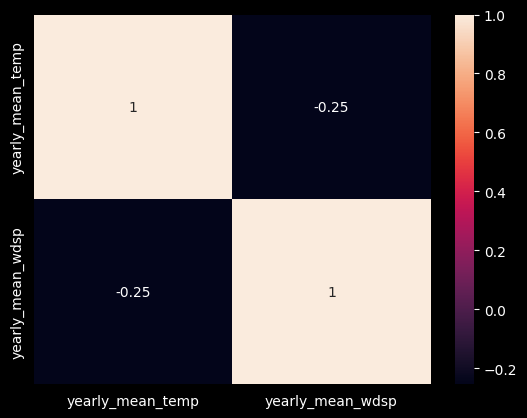

In [31]:
sns.heatmap(corr[['yearly_mean_temp', 'yearly_mean_wdsp']].loc[['yearly_mean_temp', 'yearly_mean_wdsp']], annot=True);

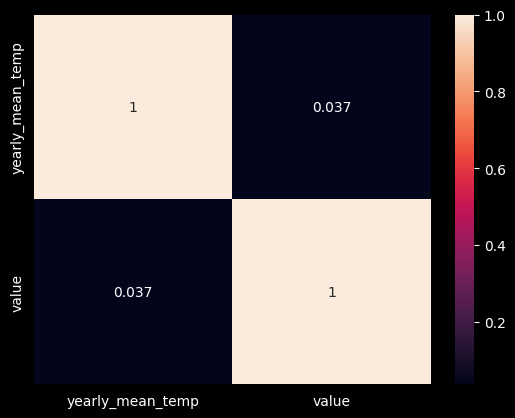

In [32]:
sns.heatmap(corr[['yearly_mean_temp', 'value']].loc[['yearly_mean_temp', 'value']], annot=True);

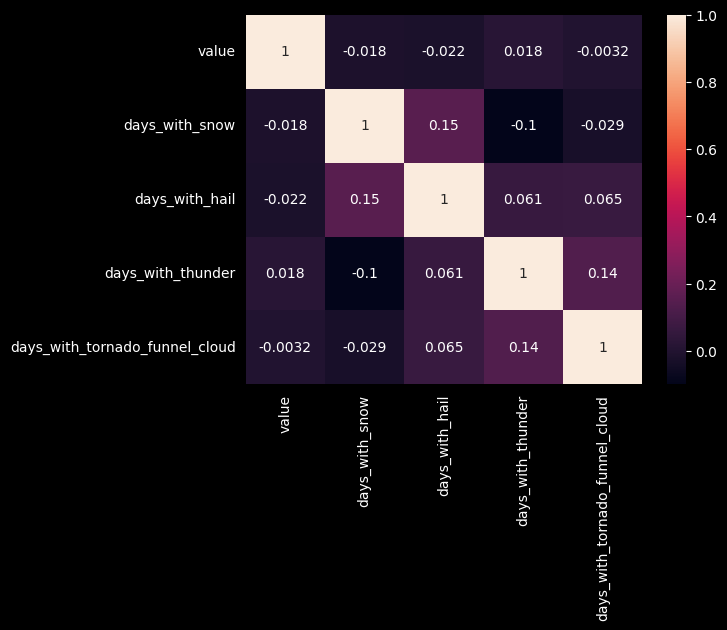

In [33]:
sns.heatmap(corr[['value', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']].loc[['value', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']], annot=True);

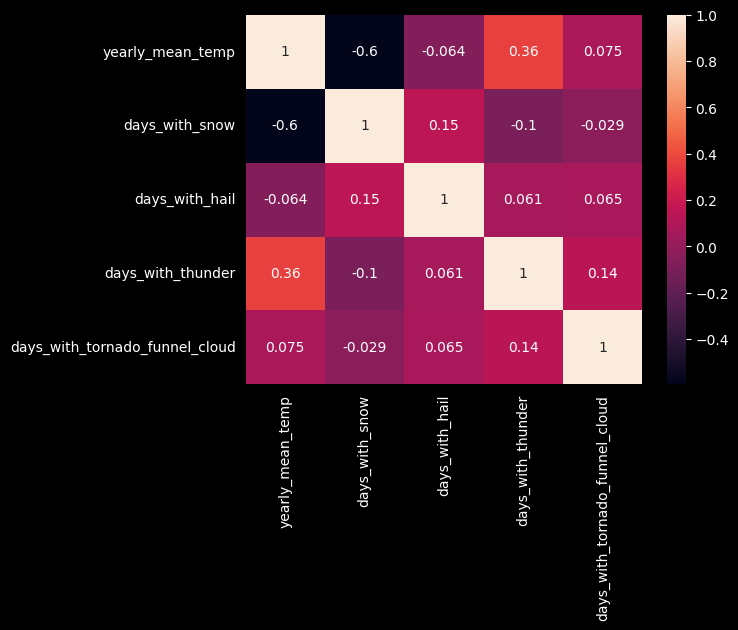

In [34]:
sns.heatmap(corr[['yearly_mean_temp', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']].loc[['yearly_mean_temp', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']], annot=True);

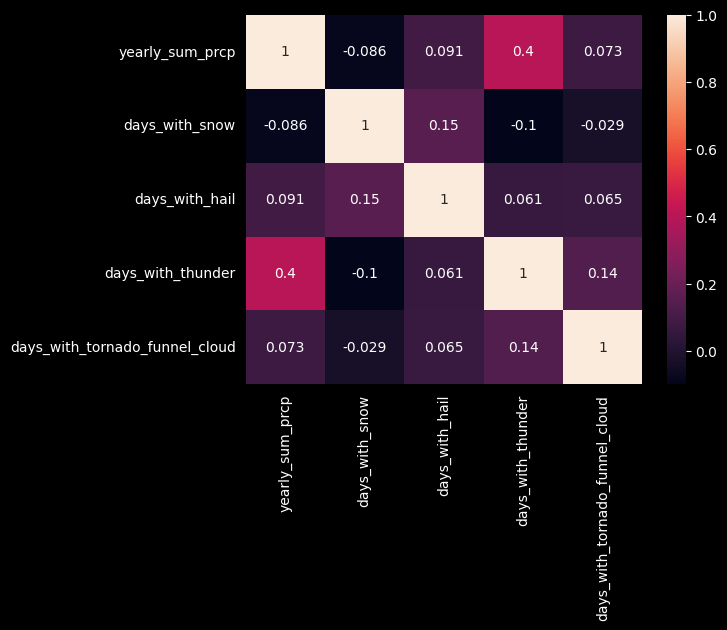

In [35]:
sns.heatmap(corr[['yearly_sum_prcp', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']].loc[['yearly_sum_prcp', 'days_with_snow', 'days_with_hail', 'days_with_thunder', 'days_with_tornado_funnel_cloud']], annot=True);

/tmp/ipykernel_246196/2475640416.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('data/car_weather.csv')


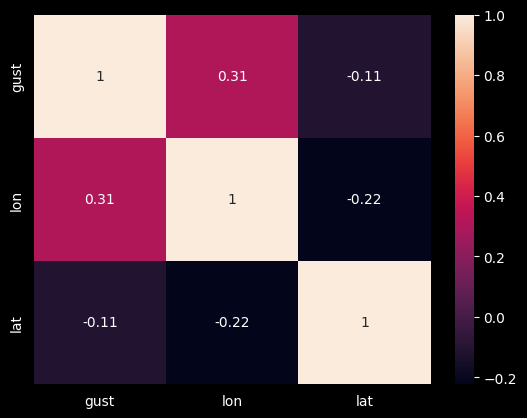

In [44]:
test = pd.read_csv('data/car_weather.csv')


corr = test.corr(numeric_only=True)
sns.heatmap(corr[['gust', 'lon', 'lat']].loc[['gust', 'lon', 'lat']], annot=True);